<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/03_ovr_large.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    df = pd.read_csv('/content/drive/MyDrive/cicids2017_cleaned.csv')
    with open('/content/drive/MyDrive/attack_features.json') as f:
        attack_features = json.load(f)
    with open('/content/drive/MyDrive/attack_groups.json') as f:
        groups = json.load(f)
    print(f"Loaded from Drive: {df.shape}")
except Exception as e:
    print(f"Drive mount failed: {e}")

Mounted at /content/drive
Loaded from Drive: (2827876, 79)


In [ ]:
# --- Config ---
LABEL_COL     = 'Label'
BENIGN_RATIO  = 5
TEST_SIZE     = 0.20
CV_SPLITS     = 3
RANDOM_STATE  = 42
AE_EPOCHS     = 10
AE_BATCH      = 256
AE_THRESHOLD_PERCENTILE = 95
MAX_ATTACK_SAMPLES = 50_000
OUTPUT_RESULTS = '/content/drive/MyDrive/results_large.json'

In [ ]:
large_attacks = groups['large']
print(f"Large attacks: {large_attacks}")
for a in large_attacks:
    print(f"  {a:<20s}: {(df[LABEL_COL] == a).sum():>7,}")

Large attacks: ['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye']
  DoS Hulk            : 230,124
  PortScan            : 158,804
  DDoS                : 128,025
  DoS GoldenEye       :  10,293


In [ ]:
from sklearn.model_selection import train_test_split

def build_ovr_dataset(df, attack, features):
    attack_mask = df[LABEL_COL] == attack
    benign_mask = df[LABEL_COL] == 'BENIGN'

    rng = np.random.RandomState(RANDOM_STATE)

    # cap attack samples
    attack_idx = df.index[attack_mask].to_numpy()
    if len(attack_idx) > MAX_ATTACK_SAMPLES:
        attack_idx = rng.choice(attack_idx, size=MAX_ATTACK_SAMPLES, replace=False)

    n_benign_target = len(attack_idx) * BENIGN_RATIO
    benign_idx = df.index[benign_mask].to_numpy()
    if len(benign_idx) > n_benign_target:
        benign_idx = rng.choice(benign_idx, size=n_benign_target, replace=False)

    combined_idx = np.concatenate([benign_idx, attack_idx])
    subset = df.loc[combined_idx]
    X = subset[features].copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    y = (subset[LABEL_COL] == attack).astype(int).values

    return train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )

In [ ]:
def train_rf(X_tr, y_tr):
    m = RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    )
    m.fit(X_tr, y_tr)
    return m

def train_xgb(X_tr, y_tr):
    pos = (y_tr == 1).sum()
    neg = (y_tr == 0).sum()
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        scale_pos_weight=neg / max(pos, 1),
        eval_metric='logloss', n_jobs=-1,
        random_state=RANDOM_STATE, verbosity=0
    )
    m.fit(X_tr, y_tr)
    return m

def train_lgb(X_tr, y_tr):
    m = lgb.LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    )
    m.fit(X_tr, y_tr)
    return m

def train_autoencoder(X_tr, y_tr):
    scaler = StandardScaler()
    X_benign = X_tr[y_tr == 0]
    X_scaled = scaler.fit_transform(X_benign)

    dim = X_scaled.shape[1]
    inp = layers.Input(shape=(dim,))
    enc = layers.Dense(dim // 2, activation='relu')(inp)
    enc = layers.Dense(max(dim // 4, 2), activation='relu')(enc)
    dec = layers.Dense(dim // 2, activation='relu')(enc)
    out = layers.Dense(dim, activation='linear')(dec)
    ae = Model(inp, out)
    ae.compile(optimizer='adam', loss='mse')
    ae.fit(X_scaled, X_scaled, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

    recon = ae.predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - recon) ** 2, axis=1)
    threshold = np.percentile(errors, AE_THRESHOLD_PERCENTILE)
    return {'model': ae, 'scaler': scaler, 'threshold': threshold}

def predict_autoencoder(ae_bundle, X):
    X_scaled = ae_bundle['scaler'].transform(X)
    recon = ae_bundle['model'].predict(X_scaled, verbose=0)
    errors = np.mean((X_scaled - recon) ** 2, axis=1)
    return (errors > ae_bundle['threshold']).astype(int)

In [ ]:
from sklearn.model_selection import StratifiedKFold

def evaluate(y_true, y_pred):
    return {
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }

MODELS = {
    'RF':       (train_rf,          lambda m, X: m.predict(X)),
    'XGBoost':  (train_xgb,         lambda m, X: m.predict(X)),
    'LightGBM': (train_lgb,         lambda m, X: m.predict(X)),
    'AE':       (train_autoencoder, predict_autoencoder),
}

results = {}

for attack in large_attacks:
    print(f"\n{'='*60}\n[{attack}]\n{'='*60}")
    feats = attack_features[attack]
    X_train, X_test, y_train, y_test = build_ovr_dataset(df, attack, feats)
    print(f"  Train: {len(X_train):,}  Test: {len(X_test):,}")
    print(f"  Train attack rate: {y_train.mean():.3f}  Test: {y_test.mean():.3f}")

    results[attack] = {}
    skf = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for model_name, (train_fn, predict_fn) in MODELS.items():
        t0 = time.time()

        # CV
        cv_scores = {'recall': [], 'precision': [], 'f1': []}
        for tr_idx, val_idx in skf.split(X_train, y_train):
            try:
                m = train_fn(X_train.iloc[tr_idx], y_train[tr_idx])
                preds = predict_fn(m, X_train.iloc[val_idx])
                s = evaluate(y_train[val_idx], preds)
                for k in cv_scores:
                    cv_scores[k].append(s[k])
            except Exception as e:
                print(f"    CV fold failed ({model_name}): {e}")

        # Final test
        m_final = train_fn(X_train, y_train)
        y_pred_test = predict_fn(m_final, X_test)
        test = evaluate(y_test, y_pred_test)

        elapsed = time.time() - t0
        results[attack][model_name] = {
            'cv_recall_mean': float(np.mean(cv_scores['recall'])),
            'cv_recall_std':  float(np.std(cv_scores['recall'])),
            'cv_f1_mean':     float(np.mean(cv_scores['f1'])),
            'test_recall':    float(test['recall']),
            'test_precision': float(test['precision']),
            'test_f1':        float(test['f1']),
            'elapsed_sec':    round(elapsed, 1),
        }
        print(f"  {model_name:<10s} "
              f"CV recall={np.mean(cv_scores['recall']):.3f}±{np.std(cv_scores['recall']):.3f}  "
              f"Test recall={test['recall']:.3f}  F1={test['f1']:.3f}  ({elapsed:.1f}s)")


[DoS Hulk]
  Train: 240,000  Test: 60,000
  Train attack rate: 0.167  Test: 0.167
  RF         CV recall=0.999±0.000  Test recall=0.999  F1=0.977  (179.4s)
  XGBoost    CV recall=0.999±0.000  Test recall=0.999  F1=0.977  (14.7s)
  LightGBM   CV recall=0.999±0.000  Test recall=0.999  F1=0.977  (17.2s)
  AE         CV recall=0.658±0.012  Test recall=0.632  F1=0.671  (112.0s)

[PortScan]
  Train: 240,000  Test: 60,000
  Train attack rate: 0.167  Test: 0.167
  RF         CV recall=1.000±0.000  Test recall=1.000  F1=0.998  (160.4s)
  XGBoost    CV recall=1.000±0.000  Test recall=1.000  F1=0.998  (15.7s)
  LightGBM   CV recall=1.000±0.000  Test recall=1.000  F1=0.998  (17.6s)
  AE         CV recall=0.016±0.008  Test recall=0.001  F1=0.001  (119.8s)

[DDoS]
  Train: 240,000  Test: 60,000
  Train attack rate: 0.167  Test: 0.167
  RF         CV recall=0.998±0.000  Test recall=0.998  F1=0.998  (78.2s)
  XGBoost    CV recall=0.998±0.000  Test recall=0.998  F1=0.997  (13.6s)
  LightGBM   CV recal

In [ ]:
with open(OUTPUT_RESULTS, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Saved: {OUTPUT_RESULTS}")

Saved: /content/drive/MyDrive/results_large.json


In [ ]:
rows = []
for attack, models in results.items():
    for model, s in models.items():
        rows.append({
            'Attack': attack,
            'Model': model,
            'CV Recall': f"{s['cv_recall_mean']:.3f}±{s['cv_recall_std']:.3f}",
            'Test Recall': round(s['test_recall'], 3),
            'Test Precision': round(s['test_precision'], 3),
            'Test F1': round(s['test_f1'], 3),
            'Time(s)': s['elapsed_sec'],
        })
comp_df = pd.DataFrame(rows).sort_values(['Attack', 'Test Recall'], ascending=[True, False])
print(comp_df.to_string(index=False))

       Attack    Model   CV Recall  Test Recall  Test Precision  Test F1  Time(s)
         DDoS       RF 0.998±0.000        0.998           0.998    0.998     78.2
         DDoS  XGBoost 0.998±0.000        0.998           0.997    0.997     13.6
         DDoS LightGBM 0.998±0.000        0.998           0.997    0.997     17.0
         DDoS       AE 0.173±0.002        0.173           0.404    0.242    104.3
DoS GoldenEye  XGBoost 0.999±0.001        1.000           0.991    0.995      3.6
DoS GoldenEye LightGBM 0.998±0.001        0.999           0.992    0.995      3.6
DoS GoldenEye       RF 0.995±0.001        0.997           0.995    0.996     38.3
DoS GoldenEye       AE 0.884±0.008        0.703           0.729    0.716     28.7
     DoS Hulk       RF 0.999±0.000        0.999           0.956    0.977    179.4
     DoS Hulk  XGBoost 0.999±0.000        0.999           0.956    0.977     14.7
     DoS Hulk LightGBM 0.999±0.000        0.999           0.956    0.977     17.2
     DoS Hulk   

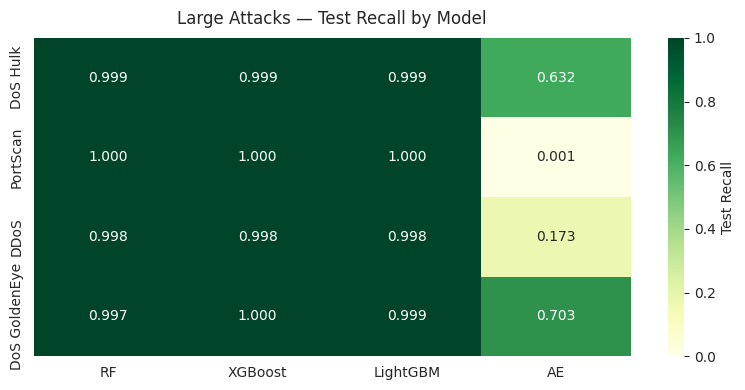

In [ ]:
heatmap_data = pd.DataFrame(
    {m: [results[a][m]['test_recall'] for a in large_attacks] for m in MODELS},
    index=large_attacks
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, cbar_kws={'label': 'Test Recall'}, ax=ax)
ax.set_title('Large Attacks — Test Recall by Model', pad=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/results_large_recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()